#**REVENUE LEAKAGE & RECONCILIATION ANALYTICS**

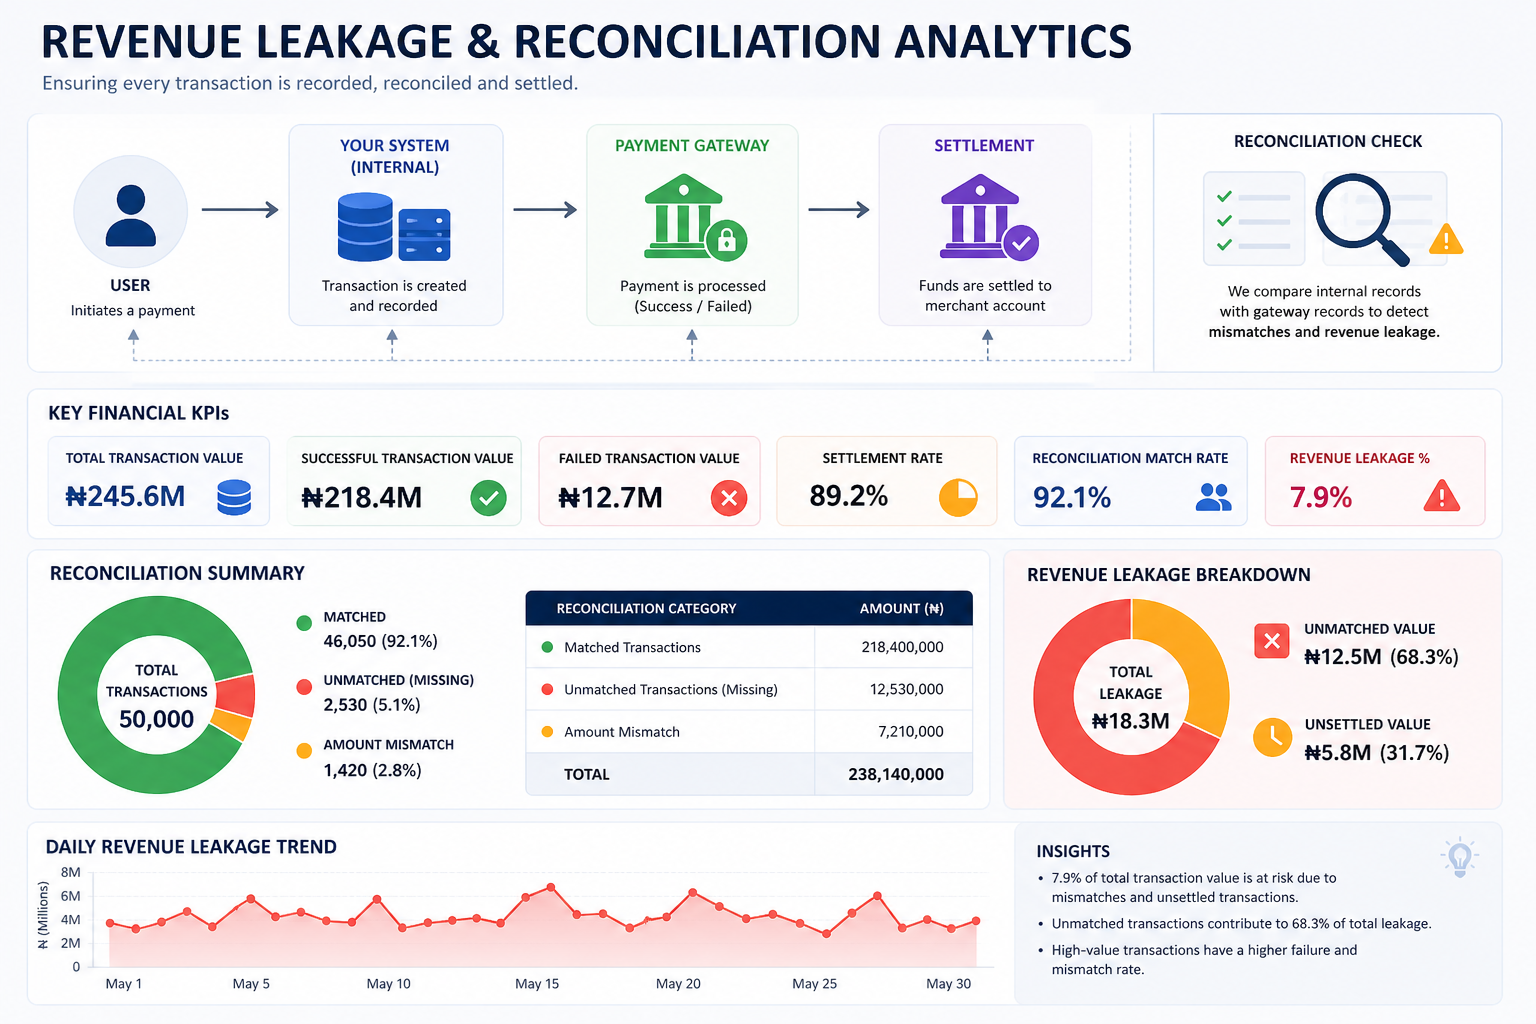

###**OVERVIEW**


This project focuses on building a reconciliation and revenue monitoring system to ensure the accuracy and integrity of financial transactions within a fintech environment.

In modern payment systems, transactions pass through multiple layers; from internal application logs to external payment processors and final settlement. Due to system errors, integration issues, or delays, discrepancies can occur between these records. These inconsistencies can lead to revenue leakage, inaccurate reporting, and operational risk.

To address this, I developed an end-to-end analytics workflow that:

* Compares internal transaction records with gateway data.
* Identifies missing, mismatched, and unsettled transactions.
* Defines key financial KPIs to monitor system health.
* Quantifies revenue leakage and highlights financial risk

The analysis combines SQL-style reconciliation logic with Python-based data processing to simulate a real-world fintech scenario.

###**BUSINESS PROBLEM**
In fintech systems, mismatches between internal transaction records and payment gateway data can lead to **revenue leakage**. This project builds a reconciliation system to detect and quantify these issues.

###**KPI DEFINITIONS**


Defining key financial metrics:
- **Total Transaction Value:** All money users tried to pay.
- **Successful Transaction Value:** Money from transactions that actually worked.
- **Failed Transaction Value:** Money from transaction that failed.
- **Settlement Rate:** Of the successful transactions, how many actually reached the bank?
- Reconciliation Match Rate: Do internal records match gateway records?
- Revenue Leakage %: How much is being lost?

###**LOAD DATASETS**
This project was carried out using two tables of simlated datasets to depict real world fintech data;
* Internal Transactions Table.
* Gateway Transactions Table.

The Internal Transaction Dataset can be found [here](https://drive.google.com/file/d/1MjbbM4eQnXICM3e9Q2iI2r-_px2HVxuz/view?usp=sharing). It consists of five columns;
```
Transaction_id
User_id
Amount
Transaction_date
Status (Initiated, Success, Failed)
```

The Gateway Transaction Dataset can be foung [here](https://drive.google.com/file/d/1pK7m0zvfeSrv4mFdEX5L7HcAQ9y9ErI8/view?usp=sharing). It consists of eight columns;
```
Transaction_id
User_id
Gateway_reference
Amount
Transaction_date
Status (Success, Failed)
Settlement_status (Settled, Pending)
Settlemet_date
```

###**Import Libraries**

In [46]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

In [47]:
# Load datasets in pandas
Gateway = pd.read_csv("gateway_transactions.csv")
Internal = pd.read_csv("internal_transactions.csv")

In [48]:
# data shape
print([Gateway.shape], [Internal.shape])

[(44963, 8)] [(50000, 5)]


The Gateway Transactions Dataset consists of **44983** rows and **8** columns.

The Internal Transactions Datatset consists of **50000** rows and **5** columns.

In [49]:
# view gateway table
Gateway.head()

,transaction_id,user_id,amount,transaction_date,status,gateway_reference,settlement_status,settlement_date
0,1,4174,1000.0,2025-04-17,initiated,GW_1,pending,NaN
1,3,1860,1000.0,2025-02-04,success,GW_3,settled,2025-02-06
2,4,2294,500.0,2025-02-23,success,GW_4,pending,NaN
3,5,2130,1000.0,2025-01-21,success,GW_5,settled,2025-01-24
4,7,4772,500.0,2025-04-22,success,GW_7,pending,NaN


In [50]:
# view internal table
Internal.head()

,transaction_id,user_id,amount,transaction_date,status
0,1,4174,1000,2025-04-17,initiated
1,2,4507,1000,2025-03-18,failed
2,3,1860,1000,2025-02-04,success
3,4,2294,500,2025-02-23,success
4,5,2130,1000,2025-01-21,success


In [51]:
# data info
print([Gateway.info()], [Internal.info()])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44963 entries, 0 to 44962
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     44963 non-null  int64  
 1   user_id            44963 non-null  int64  
 2   amount             44963 non-null  float64
 3   transaction_date   44963 non-null  object 
 4   status             44963 non-null  object 
 5   gateway_reference  44963 non-null  object 
 6   settlement_status  44963 non-null  object 
 7   settlement_date    20385 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 2.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    50000 non-null  int64 
 1   user_id           50000 non-null  int64 
 2   amount            50000 non-null  int64 
 3   transac

In [52]:
Internal.isnull().sum()

,0
transaction_id,0
user_id,0
amount,0
transaction_date,0
status,0


In [53]:
Gateway.isnull().sum()

,0
transaction_id,0
user_id,0
amount,0
transaction_date,0
status,0
gateway_reference,0
settlement_status,0
settlement_date,24578


Both Gateway & Internal Transactions Datasets have no missing rows.                                  

In [54]:
# check for duplicates
print([Gateway.duplicated().sum()], [Internal.duplicated().sum()])

[np.int64(0)] [np.int64(0)]


Both Gateway & Internal Transactions Datasetshave no duplicate rows.

###**Connect To Sqlite**

In [55]:
# create a revenue database
conn = sqlite3.connect("Revenue.db")

###**Push DataFrame Into SQL**

In [56]:
# Gateway table
Gateway.to_sql(
    "Gateway",
    conn,
    if_exists = "replace",
    index = False
)


# Internal table
Internal.to_sql(
    "Internal",
    conn,
    if_exists = "replace",
    index = False
)

50000

###**RECONCILIATION LOGIC**

###**Total Value**
All the money users tried to pay

In [57]:
query=("""
SELECT
SUM(amount) AS Total
FROM Internal
""");
pd.read_sql(query, conn)

,Total
0,98942500


The total money users tried to pay is **98,942,500.**

###**Match Transactions**
Matching transactions from the internal table to see if they actually match the gateway transactions.
If transaction doesn't appear in gateway, it return NULL.

In [58]:
query=("""
SELECT
    i.transaction_id,
    i.amount AS Internal_amount,
    g.amount AS Gateway_amount
FROM Internal i
LEFT JOIN Gateway g
ON i.transaction_id = g.transaction_id

""")
pd.read_sql(query, conn)

,transaction_id,Internal_amount,Gateway_amount
0,1,1000,1000.0
1,2,1000,NaN
2,3,1000,1000.0
3,4,500,500.0
4,5,1000,1000.0
...,...,...,...
49995,49996,1000,1000.0
49996,49997,1500,NaN
49997,49998,500,500.0
49998,49999,1000,1000.0


In [59]:
# view the first 20 transactions
query=("""
SELECT
    i.transaction_id,
    i.amount AS Internal_amount,
    g.amount AS Gateway_amount
FROM Internal i
LEFT JOIN Gateway g
ON i.transaction_id = g.transaction_id
LIMIT 20
""")
pd.read_sql(query, conn)

,transaction_id,Internal_amount,Gateway_amount
0,1,1000,1000.0
1,2,1000,NaN
2,3,1000,1000.0
3,4,500,500.0
4,5,1000,1000.0
5,6,1000,NaN
6,7,500,500.0
7,8,500,500.0
8,9,1000,1000.0
9,10,2000,1800.0


From the first 20 transactions, we can see that:
* Transactions 2, 6, and 15 are missing in gateway because there are no amount found in gateway.
* Transaction 10 is mismatched because the amount recieved in gateway is different from the amount in the internal system.

###**Missing Transactions**
Transactions in internal table but not found in the gateway table.

In [60]:
query =("""
SELECT *
FROM Internal i
LEFT JOIN Gateway g
ON i.transaction_id = g.transaction_id
WHERE g.transaction_id IS NULL
""");
pd.read_sql(query, conn)

,transaction_id,user_id,amount,transaction_date,status,transaction_id,user_id,amount,transaction_date,status,gateway_reference,settlement_status,settlement_date
0,2,4507,1000,2025-03-18,failed,None,None,None,None,None,None,None,None
1,6,2095,1000,2025-01-30,initiated,None,None,None,None,None,None,None,None
2,15,3135,500,2025-03-21,success,None,None,None,None,None,None,None,None
3,22,4380,1500,2025-01-24,success,None,None,None,None,None,None,None,None
4,37,1747,5000,2025-02-26,success,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5032,49979,4456,2000,2025-02-21,success,None,None,None,None,None,None,None,None
5033,49990,4790,1000,2025-01-08,failed,None,None,None,None,None,None,None,None
5034,49993,4950,2000,2025-02-11,success,None,None,None,None,None,None,None,None
5035,49994,4889,2000,2025-03-28,failed,None,None,None,None,None,None,None,None


**5037** internal transactions are missing in gateway.

###**Missing Value**
Amount missing

In [61]:
query = ("""
SELECT SUM(i.amount) AS Total_missing
FROM Internal i
LEFT JOIN Gateway g
ON i.transaction_id = g.transaction_id
WHERE g.transaction_id IS NULL
""");
pd.read_sql(query, conn)

,Total_missing
0,10101500


**10,101,500** is the missing value. This amount was paid but did not get to the gateway.

###**Amount Mismatch**
Amounts that got to the gateway but with a different amount

In [62]:
query =("""
SELECT
    i.transaction_id,
    i.amount AS Internal_amount,
    g.amount AS Gateway_amount
FROM Internal i
LEFT JOIN Gateway g
ON i.transaction_id = g.transaction_id
WHERE i.amount != g.amount
""");
pd.read_sql(query, conn)

,transaction_id,Internal_amount,Gateway_amount
0,10,2000,1800.0
1,28,5000,4750.0
2,32,1000,1100.0
3,38,500,525.0
4,54,1000,900.0
...,...,...,...
2243,49898,500,475.0
2244,49926,1000,1050.0
2245,49934,5000,5500.0
2246,49938,1000,950.0


**2248** transations have mismatch. What was recieved in the gateway is different from what was recieved in the internal system.

###**Missing Value From Mismatch**

Some transactions have the gateway amount as greater than the internal amount, while some transactions have the gateway amount lesser than the internal amount.

Both cases are caused by different possible reasons.

Possible causes of gateway amount being less than internal amount are;  
*   Partial payments (customer paid less than expected).
* Fees deducted before settlement.
* Currency conversion differences.
* Discounts/promos applied at gateway but not internally
* Data inconsistency / bug in internal system
* Fraud / tampering edge cases


Possible causes of gateway amount being greater than internal amount are;
* Duplicate charges.
* Incorrect pricing logic internally.
* Taxes/fees added externally but not tracked internally.
* Manual adjustments at gateway.
* Currency rounding differences.
* Fraud / overcharge.



In [63]:
# mismatch when internal is greater than gateway.
query=("""
SELECT
i.transaction_id,
i.amount AS Internal_amount,
g.amount AS Gateway_amount,
(i.amount) - (g.amount) AS Txn_diff
FROM Internal i
LEFT JOIN Gateway g
ON i.transaction_id = g.transaction_id
WHERE i.amount > g.amount
""");
pd.read_sql(query, conn)

,transaction_id,Internal_amount,Gateway_amount,Txn_diff
0,10,2000,1800.0,200.0
1,28,5000,4750.0,250.0
2,54,1000,900.0,100.0
3,83,10000,9500.0,500.0
4,90,2000,1900.0,100.0
...,...,...,...,...
1144,49874,5000,4750.0,250.0
1145,49879,500,475.0,25.0
1146,49898,500,475.0,25.0
1147,49938,1000,950.0,50.0


Out of the **2248** transactions mismatched, **1149** transactions have the internal amount lesser than gateway amount. Which means that **1099** transactions have the internal amount greater than gateway amount.

In [64]:
# amount value when internal is greater than gateway.
query=("""
  SELECT
       SUM((i.amount) - (g.amount)) AS Diff_sum
  FROM Internal i
  LEFT JOIN Gateway g
  ON i.transaction_id = g.transaction_id
  WHERE i.amount > g.amount
""");
pd.read_sql(query, conn)

,Diff_sum
0,176600.0


Total value mismatch when internal amount is greater than gateway amount is **176,600.**

In [65]:
# amount value when internal is less than gateway.
query=("""
  SELECT
       SUM((g.amount) - (i.amount)) AS Diff_sum
  FROM Internal i
  LEFT JOIN Gateway g
  ON i.transaction_id = g.transaction_id
  WHERE i.amount < g.amount
""");
pd.read_sql(query, conn)

,Diff_sum
0,152425.0


Total value mismatch when internal amount is less than gateway amount is **152,425.**

###**Unsettled Transactions**
Money that is stuck. Payment was successful but money did not get to the bank.

In [66]:
Gateway["settlement_status"].unique()

array(['pending', 'settled'], dtype=object)

In [67]:
query = ("""
SELECT
   transaction_id,
   settlement_status
FROM Gateway
WHERE settlement_status = "pending"
""");
pd.read_sql(query, conn)

,transaction_id,settlement_status
0,1,pending
1,4,pending
2,7,pending
3,8,pending
4,10,pending
...,...,...
24573,49987,pending
24574,49988,pending
24575,49989,pending
24576,49992,pending


**24578** transactions are stuck. They haven't been received by the bank yet.

###**Unsettled Value**

The value of the money stuck



In [68]:
query = ("""
SELECT
   SUM(amount) AS Total_amount
FROM Gateway
WHERE settlement_status = "pending"
""");
pd.read_sql(query, conn)

,Total_amount
0,48455200.0


The total money stuck is **48,455,200**

###**Settlement Rate**

In [69]:
query= ("""
SELECT
    SUM(CASE WHEN settlement_status = 'settled' THEN 1 ELSE 0 END) * 1.0
    / SUM(CASE WHEN status = 'success' THEN 1 ELSE 0 END)
    AS settlement_rate
FROM Gateway;
""");
pd.read_sql(query, conn)

,settlement_rate
0,0.799851


###**High-Value Failures**

In [70]:
query = ("""
SELECT
  COUNT(*) AS Total,
  ROUND(AVG(amount), 2) AS Avg_amount
FROM Internal
WHERE status = 'failed';
""");
pd.read_sql(query, conn)

,Total,Avg_amount
0,10138,1981.36


###**Time-Based Issues**

In [71]:
query = ("""
SELECT
  strftime(transaction_date) AS Date,
  COUNT(*) FILTER (WHERE status = 'failed') AS failures
FROM Internal
GROUP BY DATE(transaction_date)
""");
pd.read_sql(query, conn)

,Date,failures
0,2025-01-01,88
1,2025-01-02,78
2,2025-01-03,85
3,2025-01-04,69
4,2025-01-05,74
...,...,...
115,2025-04-26,77
116,2025-04-27,96
117,2025-04-28,74
118,2025-04-29,76


###**REVENUE LEAKAGE CALCULATION**

```
Revenue Leakage % = (unmatched + unsettled value) / Total value
```

In [72]:
query = ("""
SELECT
  (missing + unsettled) * 1.0 / total AS Leakage_rate
FROM (
  SELECT
    (SELECT SUM(amount) FROM Internal) AS total,
    (SELECT SUM(i.amount)
     FROM Internal i
     LEFT JOIN Gateway g
     ON i.transaction_id = g.transaction_id
     WHERE g.transaction_id IS NULL) AS missing,
    (SELECT SUM(amount)
    FROM Gateway
    WHERE settlement_status = 'pending') AS unsettled
)
""");
pd.read_sql(query, conn)

,Leakage_rate
0,0.591826


Leakage rate is **0.59**

###**Failure By Amount Range**

In [73]:
query = ("""
SELECT
  CASE
    WHEN amount < 1000 THEN 'Low'
    WHEN amount BETWEEN 1000 AND 5000 THEN 'Medium'
    ELSE 'High'
  END AS Range,
  COUNT(*) AS Count
FROM Internal
WHERE status = 'failed'
GROUP BY range;
""");
pd.read_sql(query,conn)

,Range,Count
0,High,489
1,Low,2041
2,Medium,7608


###**INSIGHTS & BUSINESS INTERPRETATION**


1. Significant Revenue Leakage.
* Total transaction value: ₦98,942,500
* Missing (not in gateway): ₦10,101,500
* Unsettled (stuck funds): ₦48,455,200
* Leakage rate: 59%


This shows that over half of the total transaction value is not fully realized, indicating a major breakdown in the payment pipeline.

2. High Volume of Missing Transactions.
* 5,037 transactions missing in gateway


These transactions were initiated internally but never reached the gateway. The possible issues could be;
* API/integration failures
* Network interruptions
* Dropped requests

3. Material Amount Mismatches.
* 2,248 mismatched transactions
* Internal > Gateway → ₦176,600 (revenue overstatement risk) showing financial reporting inaccuracies.
* Gateway > Internal → ₦152,425 (customer overcharge risk) showing customer trust & legal risk.



###**RECOMMENDATIONS**

1. Implement Real-Time Reconciliation System
* Automate checks for:
     * Missing Transactions.
     * Mismatches.
     * Unsettled payments.
* Run hourly or real-time.
2. Fix Integration Gaps.
* Investigate why 5,037 transactions never reached gateway
* Actions:
     * Add retry mechanisms.
     * Implement logging/monitoring for API failures.
     * Enforce transaction acknowledgment checks.

###**FINAL SUMMARY**

This analysis reveals an inefficient and high-risk payment system with:

* 59% revenue leakage.
* Large volumes of missing transactions.
* Significant unsettled funds.
* Measurable data inconsistencies